In [14]:
from dotenv import load_dotenv
load_dotenv()

True

In [15]:
from langchain_groq import ChatGroq 
from langgraph.graph import StateGraph,START,END
from pydantic import BaseModel, Field
from typing import Literal

In [16]:
# coding,google_search,weather
# Literal is used to restrict the value of category to
#  one of the specified options. This ensures that only valid categorie
#  can be assigned to the category field in the FlowState model.

class FlowState(BaseModel):
    question:str=Field(description="User question")
    category:Literal["coding","google_search","weather"]=Field(default="google_search")
    answer:str=Field(default="")

In [17]:
class QuestionCategory(BaseModel):
    category:Literal["coding","google_search","weather"]=Field(default="google_search",description="Question Category")
    


In [18]:
llm=ChatGroq(model="llama-3.3-70b-versatile")

In [19]:
def check_question_category(state:FlowState)->FlowState:
    st_llm=llm.with_structured_output(QuestionCategory)
    res=st_llm.invoke(f"I want to know the catrgory of my question: {state.question}.If you are not sure then just give 'google_search' as a category")
    state.category=res.category
    return state

In [20]:
def route(state:FlowState)->Literal["coding","google_search","weather"]:
    return state.category

In [ ]:
def coding_node(state:FlowState)->FlowState:
    print("Coding node")
    res=llm.invoke(f"You are coding expert: {state.question}")
    state.answer=res
    return state

def weather_node(state:FlowState)->FlowState:
    print("Weather node")
    res=llm.invoke(f"You are weather expert: {state.question}")
    state.answer=res
    return state

def google_search_node(state:FlowState)->FlowState:
    print("Google search node")
    res=llm.invoke(f"You are google search expert: {state.question}")
    state.answer=res
    return state

In [22]:
graph=StateGraph(FlowState)

graph.add_node("check_question_category",check_question_category)
graph.add_node("coding",coding_node)
graph.add_node("weather",weather_node)
graph.add_node("google_search",google_search_node)

In [23]:
graph.add_edge(START,"check_question_category")
graph.add_conditional_edges("check_question_category",route)
graph.add_edge("coding",END)
graph.add_edge("weather",END)
graph.add_edge("google_search",END)

graph=graph.compile()

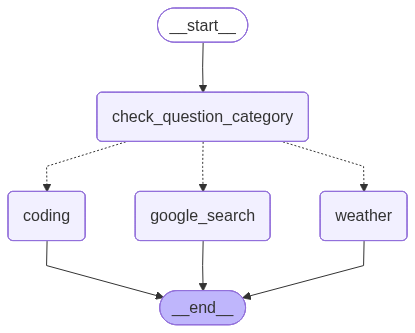

In [24]:
from IPython.display import Image 
Image(graph.get_graph().draw_mermaid_png())

In [25]:
response=graph.invoke(FlowState(question="What is the capital of France?"))